In [107]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv(('../data/citibike_weather_daily_clean.csv'))
df['ride_date'] = pd.to_datetime(df['ride_date'])
df.head()

,ride_date,num_rides,avg_duration_min,temp_f,max_temp_f,min_temp_f,wind_speed_knots,precip_in,day_of_week,month,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday,year,days_since_start
0,2013-07-01,16650,16.31,74.8,78.1,73.4,7.8,0.00,Monday,7,True,False,False,False,False,False,2013,0
1,2013-07-02,22745,15.97,76.1,82.9,73.0,8.0,0.73,Tuesday,7,False,False,False,False,True,False,2013,1
2,2013-07-03,21864,16.24,78.5,84.9,73.9,8.8,0.06,Wednesday,7,False,False,False,False,False,True,2013,2
3,2013-07-04,22326,21.22,82.0,91.0,73.9,8.6,0.96,Thursday,7,False,False,False,True,False,False,2013,3
4,2013-07-05,21842,18.04,84.4,93.0,75.9,9.0,0.00,Friday,7,False,False,False,False,False,False,2013,4


In [108]:
df.columns.tolist()

['ride_date',
 'num_rides',
 'avg_duration_min',
 'temp_f',
 'max_temp_f',
 'min_temp_f',
 'wind_speed_knots',
 'precip_in',
 'day_of_week',
 'month',
 'Monday',
 'Saturday',
 'Sunday',
 'Thursday',
 'Tuesday',
 'Wednesday',
 'year',
 'days_since_start']

In [118]:
model_columns = ['temp_f', 'precip_in', 'wind_speed_knots', 'Monday', 'Saturday', 'Sunday', 'Thursday', 'Tuesday', 'Wednesday', 'days_since_start']

X = df[model_columns]
y = df['num_rides']


In [110]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)


(1288, 10) (322, 10)
(1288,) (322,)


In [111]:
model = LinearRegression()
model.fit(X_train, y_train)

print(model.intercept_)
print(dict(zip(model_columns, model.coef_)))

-8282.96063343792
{'temp_f': np.float64(566.6500403003482), 'wind_speed_knots': np.float64(-371.1975228263141), 'precip_in': np.float64(-3874.420702677632), 'Monday': np.float64(-869.8101620695584), 'Saturday': np.float64(-5649.694412020772), 'Sunday': np.float64(-7291.441064033856), 'Thursday': np.float64(1078.4705867930327), 'Tuesday': np.float64(685.9989758215419), 'Wednesday': np.float64(1429.9308603279508), 'days_since_start': np.float64(16.40622322340886)}


I decided to use temp_f as my single temperature, because it is the actual temoperature and it would be a more accurate coefficient versus using max_temp_f and min_temp_f because they are basically the same but are still measured differently.

## M3

In [112]:
train_r2 = model.score(X_train, y_train)
test_r2 = model.score(X_test, y_test)

print(f"Train R^2: {train_r2}")
print(f"Test R^2: {test_r2}")


Train R^2: 0.7317770320575008
Test R^2: 0.743500419867458


In [113]:

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.2f} rides")
print(f"RMSE: {rmse:.2f} rides")

MAE: 6948.59 rides
RMSE: 8773.55 rides


### What is R squared and why does R Test matter more?
 
The R^2 tells us what part of the variation in ridership does the model explain. The results for my R^2 Test is 0.7435 which my model expalins about 74% of the daily variation in ridership.

The test number is more important because it is a better representation of real bike rideship perfomance, versus the training is more artificial.

### MAE and RMSE
Our prediction is typically off by about 6,949 rides.
The RMSE is 1.26x larger than the MAE. I suspect that the badly missed days are most likely holidays where ridership is probably very low.

In [114]:
# M4
df_coefficient = pd.DataFrame({'Model Columns': model_columns, 'coefficient': model.coef_}).sort_values('coefficient', key=abs, ascending=False)

print(df_coefficient)

      Model Columns  coefficient
5            Sunday -7291.441064
4          Saturday -5649.694412
2         precip_in -3874.420703
8         Wednesday  1429.930860
6          Thursday  1078.470587
3            Monday  -869.810162
7           Tuesday   685.998976
0            temp_f   566.650040
1  wind_speed_knots  -371.197523
9  days_since_start    16.406223


### Interpret The Coefficients
1. Each additional inch of rain costs us roughly 3874 rides. Rain is a very big fact in daily ridership count.
2. An average Sunday brrings in roughly 7291 less rides, which is the largest coefficient in the model meaning, most ridersare using the bikes as a means to commute to work.
3. Each additional degree in temperature brings in 566 more rides.

#### Surprises?
My only surprise is the negative coeffiecient for Monday. In my EDA led me to believe that weekdays are the days that have higher ridership, so a negative coefficient is shoking.

In [115]:
# Diagnose with Residuals
residuals = y_test - y_pred

Text(0.5, 1.0, 'Residuals vs. Predicated Values')

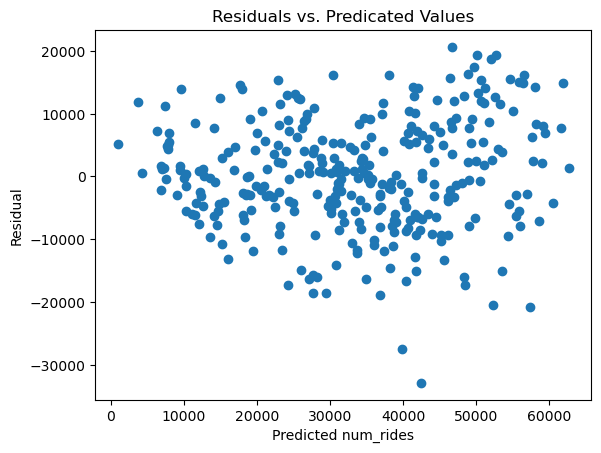

In [116]:
# Residual Against Predicated Values
plt.scatter(y_pred, residuals)
plt.xlabel('Predicted num_rides')
plt.ylabel('Residual')
plt.title('Residuals vs. Predicated Values')


Text(0.5, 1.0, 'Residual Over Time')

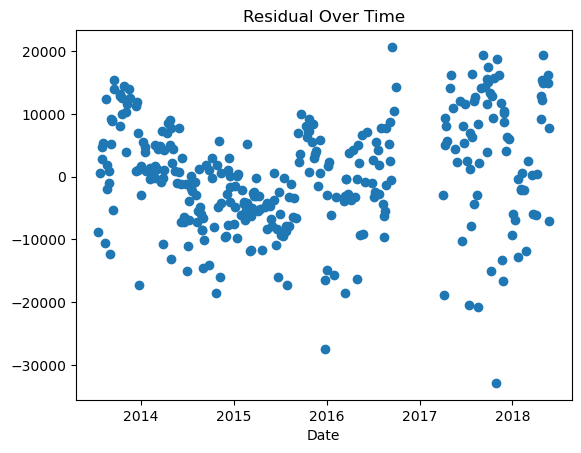

In [117]:
# Residuals Againstride_date
test_dates = df.loc[X_test.index, 'ride_date']

plt.scatter(test_dates, residuals)
plt.xlabel('Date')
plt.title('Residual Over Time')

For the Residual vs Predicted plot near the lower predicted values are the residuals are also around the same values. However as the predicted numbers increase the plots are more spreaded from -30,000 to 20,000. This means the size of the error is not consistent as the predicted value grows.
For the Residual over time the plot seems to be drifiting downwards.